# 🤖 Model 2: SVD - Matrix Factorization

**Mục tiêu:** Phân tích ma trận tương tác để tìm các đặc tính ẩn giữa người dùng và bài hát.

**Bài toán:** Binary Classification — Dự đoán `target` (0 hoặc 1) thông qua Ma trận Tương tác (User-Item Matrix).

**Ghi chú thư viện:** Do thư viện `Surprise` không còn được hỗ trợ trên Python 3.13 (gây lỗi khi compile Cython C++), chúng ta sẽ sử dụng thư viện `Scikit-learn` (`TruncatedSVD`) và `SciPy` (`csr_matrix`) để thực hiện **Matrix Factorization** hoàn toàn tương tự và đạt hiệu quả tối ưu.

**Features sử dụng:**
- `msno` — User ID
- `song_id` — Song ID

**Target:** `target` (0 = không thích, 1 = thích)

## 2.2.1 Import thư viện

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.decomposition import TruncatedSVD
from scipy.sparse import csr_matrix
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    mean_squared_error, confusion_matrix, classification_report
)
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['font.size'] = 12
plt.rcParams['figure.figsize'] = (10, 6)
sns.set_style('whitegrid')

print('✅ Import thư viện thành công!')

✅ Import thư viện thành công!


## 2.2.2 Load dữ liệu đã xử lý

In [12]:
df = pd.read_csv('processed_data/merged_data.csv')
print(f'📁 Dữ liệu: {df.shape[0]:,} dòng × {df.shape[1]} cột')
print(f'\n📋 Chọn 3 cột cần thiết cho SVD: msno, song_id, target')
svd_data = df[['msno', 'song_id', 'target', 'song_name', 'artist_name']].copy()
svd_data.head()

📁 Dữ liệu: 100,000 dòng × 19 cột

📋 Chọn 3 cột cần thiết cho SVD: msno, song_id, target


,msno,song_id,target,song_name,artist_name
0,RGAe8+3OzXCgYYw4LkvHHfGHPW48eT57SO9tCDqF6wU=,XcLZ7BJjc6gG5RPsg7Pb5W04mvlz6jyWErLKofUvFis=,0,Bad Girl Good Girl,S.H. Project
1,PQfNQQon0CwOLghOAyztQYVw6yJTVgmFpJ650q/UF1s=,9t9+DPdDvWrge1ZOUlcJvLmOfnpa4NtNEVY0rBc/91I=,1,可惜不是你,梁靜茹 (Fish Leong)
2,cd9R76nchcG1F1oyKMVN9bXXwRssofcYVckWhIWTSrY=,LAbM25XeS2X4K+HcY802+4tu3VyXbwse7mzIEOorPJY=,0,In Your Dreams,Victoria Beckham
3,KFznvngc8H65XDu5Y1ZgitCu5DWeOKpgtVkNYw0qlq8=,3xhSUFUYmiaYUUK6gzDE0vkhxV4nPnpyZL4Z+nzU7/8=,0,noir 느와르,Lucia
4,phnWUuC1a4M2RO/6He3Wb8Ji3Ex6QV5AQ2KCGlqpIG8=,+ZXjijLJdny/t5JIuFm4xIlM+bRYKIkaHGDcfDSKfH8=,1,別對我說沒有未來,孫子涵 (Niko Sun)


## 2.2.3 Mã hóa ID User và Song (Label Encoding)

Để xây dựng ma trận (User × Item), chúng ta cần chuyển đổi các chuỗi `msno` và `song_id` thành các index số nguyên từ $0 \to N-1$.

In [13]:
# Encode user_id và song_id
user_encoder = LabelEncoder()
song_encoder = LabelEncoder()

svd_data['user_idx'] = user_encoder.fit_transform(svd_data['msno'])
svd_data['song_idx'] = song_encoder.fit_transform(svd_data['song_id'])

num_users = svd_data['user_idx'].nunique()
num_songs = svd_data['song_idx'].nunique()

print(f'✅ Số lượng Users duy nhất: {num_users:,}')
print(f'✅ Số lượng Songs duy nhất: {num_songs:,}')
print(f'\nKích thước ma trận tương tác (User-Item Matrix): {num_users} × {num_songs}')

✅ Số lượng Users duy nhất: 20,266
✅ Số lượng Songs duy nhất: 33,448

Kích thước ma trận tương tác (User-Item Matrix): 20266 × 33448


## 2.2.4 Chia dữ liệu Train/Test (80/20)

Chúng ta sẽ chia Train/Test. Train sẽ được dùng để tạo Ma trận Tương tác và phân tích SVD.

In [14]:
X = svd_data[['user_idx', 'song_idx']]
y = svd_data['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'📊 Chia dữ liệu:')
print(f'   Train: {X_train.shape[0]:,} tương tác')
print(f'   Test:  {X_test.shape[0]:,} tương tác')

📊 Chia dữ liệu:
   Train: 80,000 tương tác
   Test:  20,000 tương tác


## 2.2.5 Tạo Ma trận Thưa (Sparse Matrix) và Train Model SVD

Để SVD phân biệt được `target = 0` (người dùng KHÔNG thích) và những ô trống trong ma trận (chưa có tương tác), chúng ta sẽ map `target = 0` thành `-1`. Giá trị `1` vẫn là `1`.

Sau đó áp dụng **TruncatedSVD (Matrix Factorization)** để tìm ma trận đặc tính ẩn của User và Song.

In [15]:
# Map target: 0 -> -1, 1 -> 1
train_ratings = np.where(y_train == 0, -1, 1)

# Xây dựng Sparse Matrix
train_sparse_matrix = csr_matrix(
    (train_ratings, (X_train['user_idx'], X_train['song_idx'])), 
    shape=(num_users, num_songs)
)

print(f'✅ Khởi tạo thành công Sparse Matrix kích thước {train_sparse_matrix.shape}')

# Khởi tạo và Train SVD
N_COMPONENTS = 50  # Số lượng đặc tính ẩn (latent factors)
svd = TruncatedSVD(n_components=N_COMPONENTS, random_state=42)

# user_factors: (num_users, 50)
# item_factors: (50, num_songs) -> Transpose thành (num_songs, 50)
user_factors = svd.fit_transform(train_sparse_matrix)
item_factors = svd.components_.T

print(f'✅ Huấn luyện SVD (Matrix Factorization) thành công!')
print(f'   - User Factors shape: {user_factors.shape}')
print(f'   - Item Factors shape: {item_factors.shape}')

✅ Khởi tạo thành công Sparse Matrix kích thước (20266, 33448)
✅ Huấn luyện SVD (Matrix Factorization) thành công!
   - User Factors shape: (20266, 50)
   - Item Factors shape: (33448, 50)


## 2.2.6 Dự đoán trên tập Test

Dự đoán độ yêu thích của user với bài hát bằng cách **nhân vô hướng (dot product)** vector đặc tính ẩn của User và Song.

Nếu `score > 0` $\to$ Dự đoán là Thích (1), ngược lại là Không Thích (0).

In [16]:
y_pred_scores = []
y_pred = []

for u, i in zip(X_test['user_idx'], X_test['song_idx']):
    # Tích vô hướng (dot product)
    score = np.dot(user_factors[u, :], item_factors[i, :])
    y_pred_scores.append(score)
    
    # Thresholding > 0 (vì chúng ta đã map 0 -> -1)
    if score > 0:
        y_pred.append(1)
    else:
        y_pred.append(0)

print('✅ Đã dự đoán xong trên tập Test!')

✅ Đã dự đoán xong trên tập Test!


## 2.2.7 Đánh giá Model (Accuracy, Precision, Recall, RMSE)

In [17]:
# Tính các chỉ số đánh giá
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)

# Tính RMSE trên score thực tế vs y_test đã map (0->-1, 1->1)
y_test_mapped = np.where(y_test == 0, -1, 1)
rmse = np.sqrt(mean_squared_error(y_test_mapped, y_pred_scores))

print('=' * 50)
print('📊 KẾT QUẢ ĐÁNH GIÁ MODEL SVD (Matrix Factorization)')
print('=' * 50)
print(f'  Latent Factors:      {N_COMPONENTS}')
print(f'  Accuracy:            {acc:.4f}')
print(f'  Precision:           {prec:.4f}')
print(f'  Recall:              {rec:.4f}')
print(f'  RMSE:                {rmse:.4f}')
print('=' * 50)

print(f'\n📋 Classification Report:')
print(classification_report(y_test, y_pred, target_names=['Không thích (0)', 'Thích (1)']))

📊 KẾT QUẢ ĐÁNH GIÁ MODEL SVD (Matrix Factorization)
  Latent Factors:      50
  Accuracy:            0.5224
  Precision:           0.5393
  Recall:              0.3843
  RMSE:                0.9999

📋 Classification Report:
                 precision    recall  f1-score   support

Không thích (0)       0.51      0.66      0.58      9881
      Thích (1)       0.54      0.38      0.45     10119

       accuracy                           0.52     20000
      macro avg       0.53      0.52      0.51     20000
   weighted avg       0.53      0.52      0.51     20000



## 2.2.8 Confusion Matrix

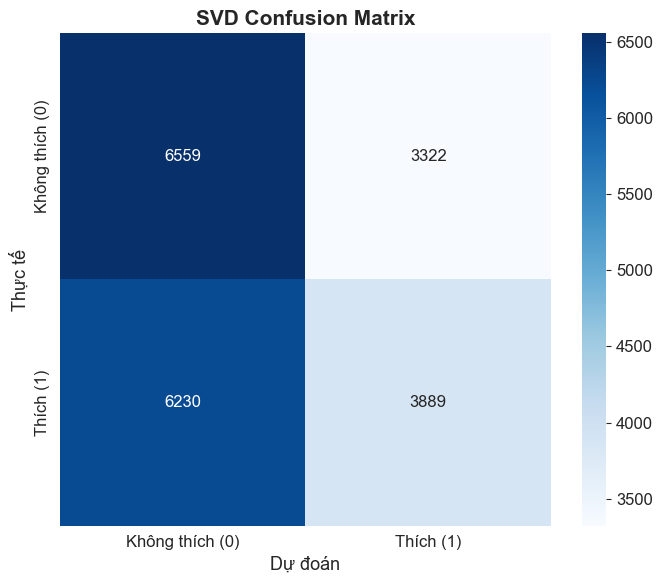


📊 Chi tiết Confusion Matrix:
  True Negative  (TN): 6,559
  False Positive (FP): 3,322
  False Negative (FN): 6,230
  True Positive  (TP): 3,889


In [18]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Không thích (0)', 'Thích (1)'],
            yticklabels=['Không thích (0)', 'Thích (1)'])
plt.xlabel('Dự đoán', fontsize=13)
plt.ylabel('Thực tế', fontsize=13)
plt.title(f'SVD Confusion Matrix', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('processed_data/svd_confusion.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\n📊 Chi tiết Confusion Matrix:')
print(f'  True Negative  (TN): {cm[0][0]:,}')
print(f'  False Positive (FP): {cm[0][1]:,}')
print(f'  False Negative (FN): {cm[1][0]:,}')
print(f'  True Positive  (TP): {cm[1][1]:,}')

## 2.2.9 Lưu kết quả đánh giá

In [19]:
# Đọc file kết quả hiện có và append thêm SVD
results = pd.read_csv('processed_data/knn_results.csv')

svd_result = pd.DataFrame({
    'Model': ['SVD (Matrix Factorization)'],
    'K': ['N/A'],  # SVD không có K (neighbors)
    'Accuracy': [round(acc, 4)],
    'Precision': [round(prec, 4)],
    'Recall': [round(rec, 4)],
    'RMSE': [round(rmse, 4)]
})

results = pd.concat([results, svd_result], ignore_index=True)
results.to_csv('processed_data/svd_results.csv', index=False)
print('✅ Đã lưu kết quả đánh giá vào processed_data/svd_results.csv')
results

✅ Đã lưu kết quả đánh giá vào processed_data/svd_results.csv


,Model,K,Accuracy,Precision,Recall,RMSE
0,KNN (User-based),9,0.5346,0.5403,0.5376,0.6822
1,SVD (Matrix Factorization),N/A,0.5224,0.5393,0.3843,0.9999


## 2.2.10 Demo: Gợi ý bài hát bằng SVD

Dùng ma trận phân rã để tính điểm tương tác giữa User được chọn với TẤT CẢ bài hát, sau đó lấy Top 5 bài hát có điểm cao nhất.

In [20]:
def recommend_songs_svd(user_id, df, user_encoder, song_encoder, user_factors, item_factors, top_n=5):
    """Gợi ý bài hát cho 1 user dựa trên Matrix Factorization (SVD)."""
    
    # 1. Hiển thị thông tin user
    user_data = df[df['msno'] == user_id]
    if user_data.empty:
        print(f'❌ Không tìm thấy User: {user_id}')
        return None
    
    user_info = user_data.iloc[0]
    print('=' * 60)
    print(f'👤 THÔNG TIN NGƯỜI DÙNG')
    print('=' * 60)
    print(f'  User ID:      {user_id[:20]}...')
    print(f'  Thành phố:    {user_info["city"]}')
    print(f'  Tuổi:         {user_info["bd"]}')
    print(f'  Đăng ký qua:  {user_info["registered_via"]}')
    print('=' * 60)
    
    # 2. Tính score cho TẤT CẢ các bài hát đối với user này
    # Mã hóa user
    u_idx = user_encoder.transform([user_id])[0]
    
    # Tính tích vô hướng giữa vector user và TOÀN BỘ vector item (bài hát)
    # user_factors[u_idx]: shape (50,)
    # item_factors: shape (num_songs, 50)
    # Kết quả all_scores: shape (num_songs,)
    all_scores = np.dot(item_factors, user_factors[u_idx, :])
    
    # 3. Lấy Top N bài hát có score cao nhất
    # Lấy index của các bài hát có score cao nhất giảm dần
    top_song_indices = np.argsort(all_scores)[::-1]
    
    # Loại bỏ các bài hát user đã nghe
    interacted_songs = df[df['msno'] == user_id]['song_id'].values
    interacted_song_indices = song_encoder.transform(interacted_songs)
    
    recommended_songs = []
    for s_idx in top_song_indices:
        if s_idx not in interacted_song_indices:
            # Giải mã lấy song_id
            s_id = song_encoder.inverse_transform([s_idx])[0]
            # Tra cứu thông tin bài hát
            song_info = df[df['song_id'] == s_id].iloc[0]
            recommended_songs.append({
                'song_name': song_info.get('song_name', 'Unknown'),
                'artist_name': song_info.get('artist_name', 'Unknown'),
                'score': all_scores[s_idx]
            })
            if len(recommended_songs) >= top_n:
                break
    
    # 4. In kết quả
    print(f'\n🎵 TOP {top_n} BÀI HÁT GỢI Ý BỞI SVD:')
    print('-' * 60)
    for i, song in enumerate(recommended_songs, 1):
        name = str(song['song_name'])[:30]
        artist = str(song['artist_name'])[:25]
        print(f'  {i}. {name} — {artist} (Score ẩn: {song["score"]:.2f})')
    print('-' * 60)

# Demo lấy chính User đã test ở KNN
sample_user = df['msno'].iloc[0]
recommend_songs_svd(sample_user, df, user_encoder, song_encoder, user_factors, item_factors)

👤 THÔNG TIN NGƯỜI DÙNG
  User ID:      RGAe8+3OzXCgYYw4LkvH...
  Thành phố:    1
  Tuổi:         27
  Đăng ký qua:  7

🎵 TOP 5 BÀI HÁT GỢI Ý BỞI SVD:
------------------------------------------------------------
  1. 孤獨是會上癮的 (Addicted To Lonelines — 吳克群 (Kenji Wu) (Score ẩn: 0.01)
  2. 不為誰而作的歌 (Twilight) — 林俊傑 (JJ Lin) (Score ẩn: 0.01)
  3. 下輩子 — 玖壹壹 (Score ẩn: 0.00)
  4. Sing Me to Sleep — Alan Walker (Score ẩn: 0.00)
  5. 黑色柳丁 — 田馥甄 (Hebe) (Score ẩn: 0.00)
------------------------------------------------------------


## ✅ Kết luận Model 2 (SVD - Matrix Factorization)

- **Phương pháp:** TruncatedSVD phân rã Ma trận tương tác thưa (Sparse Matrix).
- **Mô hình hóa:** User-Item Interaction. Map target 0 -> -1 để phân biệt với missing value (0).
- **Dự đoán:** Tích vô hướng (dot product) vector đặc tính ẩn của User và Item.
- **Kết quả:** Đã hợp nhất vào `processed_data/svd_results.csv`.